## Données images Apprentissage Automatique

Le modèle utilisé pour la classification binaire (smiling or not) est un ResNet18 pré-entrainé fine tuné sur les données de CelebA. 
Ce choix a été effectué car il nous donnera de meilleur résultat qu'un CNN from scratch.
Cela permettra de se concentré sur les biais du modèle plutot que sont "manque de performance".
Le ResNet18 n'est pas trop lourd ni trop profond pour éviter les overfitting.

In [2]:
import torchvision.models as models
import torch.nn as nn
import torch
import pandas as pd
import os
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm.notebook import tqdm 
from tqdm.notebook import tqdm, trange

In [1]:
import sys
print("Python:", sys.version)

import torch; print("torch:", torch.__version__)
import torchvision; print("torchvision:", torchvision.__version__)
import numpy; print("numpy:", numpy.__version__)
import pandas; print("pandas:", pandas.__version__)
import matplotlib; print("matplotlib:", matplotlib.__version__)


Python: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
numpy: 1.26.4
pandas: 3.0.0
matplotlib: 3.10.8


In [2]:
import torch
print(torch.__version__)   
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

print(torch.version.cuda)           # version CUDA que torch attend
print(torch.cuda.device_count())    # nombre de GPU détectés


2.5.1+cu121
True
NVIDIA GeForce RTX 4060 Laptop GPU
12.1
1


In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB utilisés")

True
0.0 GB utilisés


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch
import pandas as pd
import os
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm.notebook import tqdm 
from tqdm.notebook import tqdm, trange

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CelebADataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label  = torch.tensor((row["Smiling"] + 1) / 2, dtype=torch.float32)
        gender = torch.tensor((row["Male"]    + 1) / 2, dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label, gender


BASE_DIR   = os.getcwd()
CELEBA_DIR = os.path.join(BASE_DIR, "data", "CelebA")

dataset = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=transform
)

batch_size = 256

train_size = int(0.8 * len(dataset))
val_size   = int(0.1 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)


def make_loader(ds, shuffle):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0, 
        pin_memory=True
    )

train_loader = make_loader(train_dataset, shuffle=True)
val_loader   = make_loader(val_dataset,   shuffle=False)
test_loader  = make_loader(test_dataset,  shuffle=False)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 1)
model    = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)


def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=False)
    for imgs, labels, genders in pbar:
        imgs   = imgs.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += ((preds.sigmoid() > 0.5) == labels).sum().item()
        total      += labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

    return total_loss / len(loader), correct / total


def eval_model(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_genders = [], [], []

    pbar = tqdm(loader, desc="Evaluating", leave=False)
    with torch.no_grad():
        for imgs, labels, genders in pbar:
            imgs   = imgs.to(device)
            labels = labels.to(device).unsqueeze(1)

            preds       = model(imgs)
            total_loss += criterion(preds, labels).item()
            correct    += ((preds.sigmoid() > 0.5) == labels).sum().item()
            total      += labels.size(0)

            all_preds.append(preds.sigmoid().cpu())
            all_labels.append(labels.cpu())
            all_genders.append(genders.cpu())

            pbar.set_postfix(loss=f"{total_loss/len(loader):.4f}", acc=f"{correct/total:.4f}")

    all_preds   = torch.cat(all_preds).squeeze()
    all_labels  = torch.cat(all_labels).squeeze()
    all_genders = torch.cat(all_genders).squeeze()

    return total_loss / len(loader), correct / total, all_preds, all_labels, all_genders

epochs = 5

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []
for e in trange(epochs, desc="Epochs"):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc, _, _, _ = eval_model(model, val_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(
        f"Epoch {e+1}/{epochs} | "
        f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
        f"Val   loss: {val_loss:.4f} acc: {val_acc:.4f}"
    )
test_loss, test_acc, all_preds, all_labels, all_genders = eval_model(model, test_loader)
print(f"\nTest loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")
MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODEL_DIR / "resnet18.pt"
torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs":     epochs,
    "batch_size": batch_size,
    "test_loss":  test_loss,
    "test_acc":   test_acc,
    "all_preds":    all_preds,
    "all_labels":   all_labels,
    "all_genders":  all_genders,
    "test_indices": test_dataset.indices,  
    "binary_preds": (all_preds > 0.5).float(),
    "train_losses": train_losses,
    "train_accs":   train_accs,
    "val_losses":   val_losses,
    "val_accs":     val_accs,
}, save_path)

print(f"Modèle sauvegardé dans {save_path}")

Les entrainements étant très long avec un notebook sous Windows (dû à l'impossibilité de faire de la parallélisation avec le CPU pour le traitement des images), ceux-ci on etait réaliser avec un fichier .py annexe. Le code reste globalement le même que celui-ci dessus mais avec un main en plus et de la parallélisation de CPU. 

# Description des résultats

Epoch 1/5 | Train loss: 0.4860 acc: 0.7671 | Val   loss: 0.4580 acc: 0.7830

Epoch 2/5 | Train loss: 0.4506 acc: 0.7888 | Val   loss: 0.4468 acc: 0.7879                

Epoch 3/5 | Train loss: 0.4452 acc: 0.7911 | Val   loss: 0.4392 acc: 0.7966

Epoch 4/5 | Train loss: 0.4424 acc: 0.7937 | Val   loss: 0.4396 acc: 0.7959                 

Epoch 5/5 | Train loss: 0.4409 acc: 0.7943 | Val   loss: 0.4352 acc: 0.7984


Test loss: 0.4388 | Test acc: 0.7947
Modèle sauvegardé dans saved_models\resnet18.pt

# Evaluation de l'équité

Accuracy gap : écart d'accuracy Homme vs Femme
FPR gap : le modèle prédit-il plus souvent "sourit" à tort pour un groupe ?
FNR gap : le modèle rate-t-il plus souvent un sourire pour un groupe ?

In [3]:
def fairness_report(all_preds, all_labels, all_genders):
    binary_preds = (all_preds > 0.5).float()
    groups = {"Femmes": 0.0, "Hommes":1.0}
    accs, fprs, fnrs = {}, {}, {}

    for name, g_vals in groups.items():
        mask = (all_genders == g_vals)
        g_preds = binary_preds[mask]
        g_labels = all_labels[mask]

        acc = (g_preds == g_labels).float().mean().item()
        neg_mask = (g_labels == 0)
        pos_mask = (g_labels == 1)

        fpr = (g_preds[neg_mask] == 1).float().mean().item() if neg_mask.sum() > 0 else float("nan")
        fnr = (g_preds[pos_mask] == 0).float().mean().item() if pos_mask.sum() > 0 else float("nan")
        
        accs[name] = acc
        fprs[name] = fpr
        fnrs[name] = fnr

        n = mask.sum().item()
        print(f"  {name:8s} ({n:6d} imgs) | Accuracy: {acc:.4f} | FPR: {fpr:.4f} | FNR: {fnr:.4f}")

    print(f"\n  Écart Accuracy : {abs(accs['Femmes'] - accs['Hommes']):.4f}")
    print(f"Écart FPR : {abs(fprs['Femmes'] - fprs['Hommes']):.4f}")
    print(f"Écart FNR : {abs(fnrs['Femmes'] - fnrs['Hommes']):.4f}")
    

checkpoint = torch.load("saved_models/resnet18.pt")

all_preds = checkpoint["all_preds"]
all_labels = checkpoint["all_labels"]
all_genders = checkpoint["all_genders"]

fairness_report(all_preds, all_labels,all_genders)

C:\Users\fanny\AppData\Local\Temp\ipykernel_85224\1605011051.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("saved_models/resnet18.pt")


  Femmes   ( 11799 imgs) | Accuracy: 0.8058 | FPR: 0.1852 | FNR: 0.2016
  Hommes   (  8462 imgs) | Accuracy: 0.7791 | FPR: 0.1561 | FNR: 0.3146

  Écart Accuracy : 0.0267
Écart FPR : 0.0291
Écart FNR : 0.1131


Analyse des résultats :
Accuracy

Femmes : 80.58% vs Hommes : 77.91%
Écart de 2.67% → faible, le modèle performe de façon similaire sur les deux groupes

FPR (False Positive Rate) — prédit "sourit" alors qu'il ne sourit pas

Femmes : 18.52% vs Hommes : 15.61%
Écart de 2.91% → faible, le modèle se trompe légèrement plus sur les femmes

FNR (False Negative Rate) — prédit "ne sourit pas" alors qu'il sourit 

Femmes : 20.16% vs Hommes : 31.46%
Écart de 11.31% → problème significatif !

# Explication post-hoc

## GradCAM

In [32]:
test_indices = checkpoint["test_indices"]

binary_preds = checkpoint["binary_preds"].squeeze()
all_labels   = checkpoint["all_labels"].squeeze()
all_genders  = checkpoint["all_genders"].squeeze()

correct_mask    = (binary_preds == all_labels)
incorrect_mask  = (binary_preds != all_labels)
minority_mask   = (all_genders == 1.0)  

correct_female = (correct_mask & (all_genders == 0.0)).nonzero(as_tuple=True)[0]
idx_correct = correct_female[0].item()

incorrect_indices = (incorrect_mask & (all_genders == 0.0)).nonzero(as_tuple=True)[0]
idx_incorrect = incorrect_indices[0].item()

minority_incorrect = (incorrect_mask & minority_mask).nonzero(as_tuple=True)[0]
idx_minoritaire = minority_incorrect[0].item()



In [29]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CelebADataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label  = torch.tensor((row["Smiling"] + 1) / 2, dtype=torch.float32)
        gender = torch.tensor((row["Male"] + 1) / 2, dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label, gender


BASE_DIR = os.getcwd()
CELEBA_DIR = os.path.join(BASE_DIR, "data", "CelebA")

dataset = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=transform
)


In [30]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features,1)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()


target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

def affiche_gradcam(dataset, dataset_idx, titre):
    row      = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil  = Image.open(img_path).convert("RGB")
    img_pil  = img_pil.resize((224, 224))
    img_np   = np.array(img_pil) / 255.0 

    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor).sigmoid().item()

    label  = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    targets   = [BinaryClassifierOutputTarget(0)]
    grayscale = cam(input_tensor=img_tensor, targets=targets)
    heatmap   = show_cam_on_image(img_np.astype(np.float32), grayscale[0], use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(  
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'} | "  
        f"Pred: {'Sourit' if pred > 0.5 else 'Ne sourit pas'} ({pred:.2f}) | {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("GradCAM")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

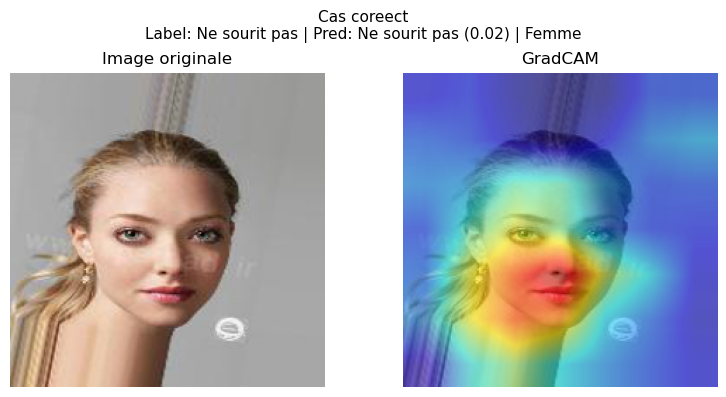

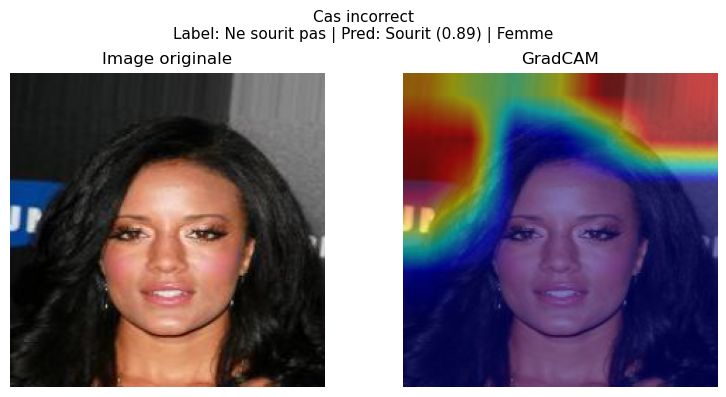

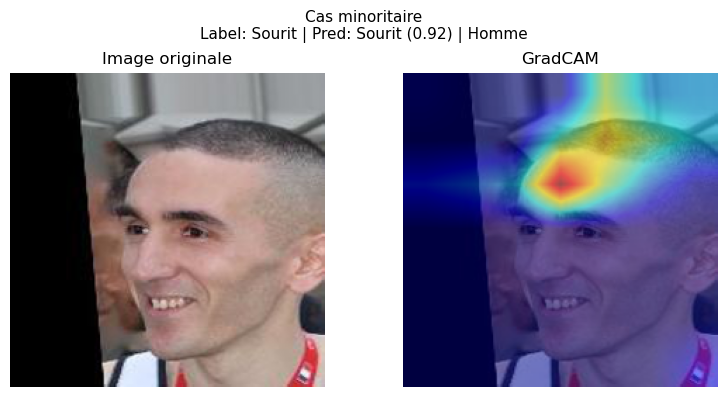

In [33]:
affiche_gradcam(dataset, test_indices[idx_correct], "Cas coreect")
affiche_gradcam(dataset, test_indices[idx_incorrect], "Cas incorrect")
affiche_gradcam(dataset, test_indices[idx_minoritaire], "Cas minoritaire")


Cas correct 
Le modèle est très confiant (0.02 = loin du seuil 0.5). La heatmap se concentre sur le bas du visage (bouche/joues), c'est exactement la bonne zone pour détecter un sourire. Le modèle a appris le bon concept ici.

Cas incorrect 
Le modèle est très confiant mais faux. La heatmap montre qu'il regarde les cheveux et le fond plutôt que la bouche. Le modèle a probablement été trompé par des corrélats spurieux, peut-être les cheveux longs, le maquillage, ou la luminosité associés aux images de sourire dans CelebA.

Cas minoritaire
Prédit correctement mais la heatmap se concentre sur le crâne/front plutôt que la bouche. Le modèle arrive à la bonne réponse mais pour les mauvaises raisons, ce qui est préoccupant et cohérent avec le FNR élevé chez les hommes (31%).

## LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

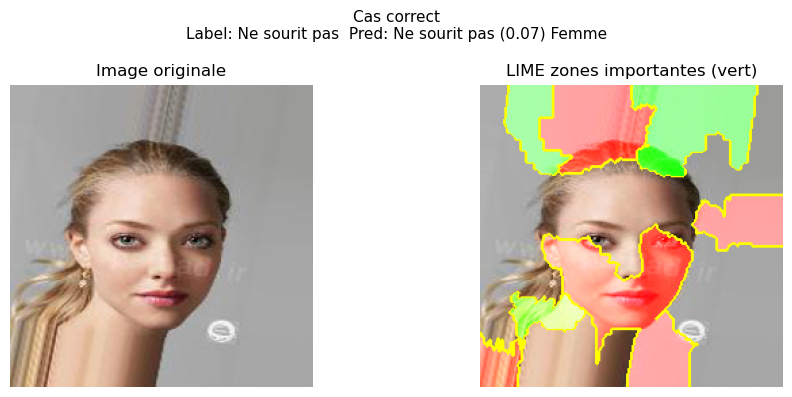

  0%|          | 0/1000 [00:00<?, ?it/s]

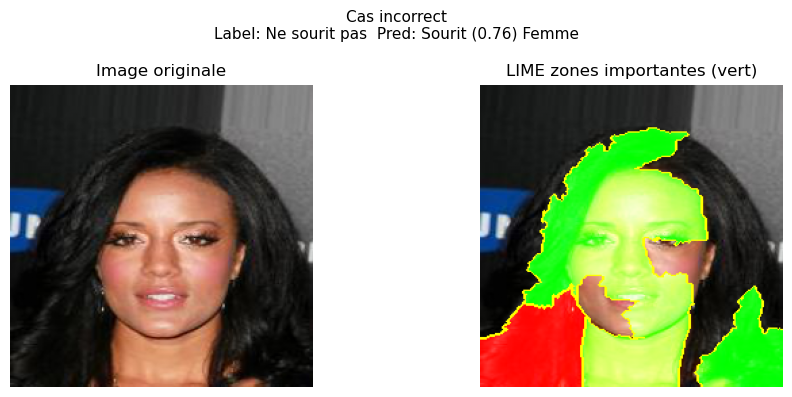

  0%|          | 0/1000 [00:00<?, ?it/s]

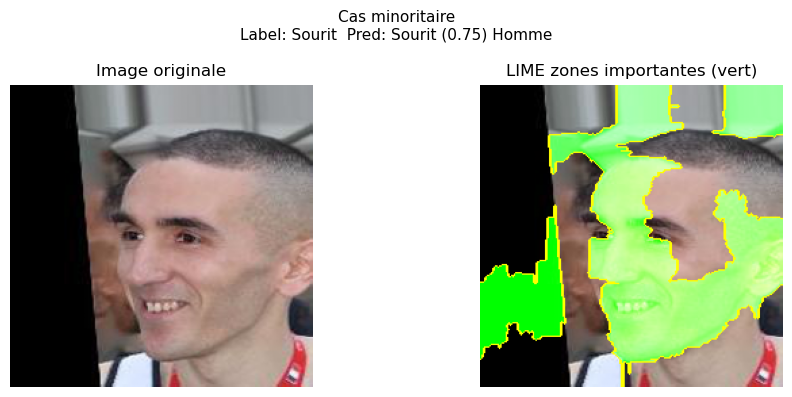

In [46]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch


def model_predict_lime(images_np):
    model.eval()
    batch = []
    for img in images_np:

        img_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])(Image.fromarray((img * 255).astype(np.uint8)))
        batch.append(img_tensor)

    batch = torch.stack(batch).to(device)
    with torch.no_grad():
        preds = model(batch).sigmoid().cpu().numpy()

    return np.column_stack([1 - preds, preds])


def afficher_lime(dataset, dataset_idx, titre):
    row = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np = np.array(img_pil) / 255.0  # float [0,1]

    label = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(img_tensor).sigmoid().item()


    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np.astype(np.double),
        model_predict_lime,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'}  "
        f"Pred: {'Sourit' if pred>0.5 else 'Ne sourit pas'} ({pred:.2f}) {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title("LIME zones importantes (vert)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

afficher_lime(dataset, test_indices[idx_correct], "Cas correct")
afficher_lime(dataset, test_indices[idx_incorrect], "Cas incorrect")
afficher_lime(dataset, test_indices[idx_minoritaire], "Cas minoritaire")

Cas correct 
Le modèle regarde les yeux et le haut du visage (vert) pour confirmer l'absence de sourire, et la bouche/lèvres (rouge) comme zone contradictoire. La prédiction est correcte mais le modèle ne se concentre pas uniquement sur la bouche il utilise l'ensemble du visage.

Cas incorrect
Le modèle a été trompé par le visage entier et les cheveux (vert). La zone bouche/menton est en rouge (opposée) paradoxalement la seule zone pertinente est celle que le modèle ignore ! Cela confirme qu'il s'appuie sur des corrélats spurieux comme le teint, le maquillage ou la luminosité.

Cas minoritaire
Le modèle prédit correctement mais regarde surtout le fond et le crâne (vert) plutôt que la bouche. La prédiction est bonne mais pour les mauvaises raisons, ce qui explique pourquoi le modèle échoue souvent sur les hommes (FNR 31%).

Les deux méthodes (GradCAM + LIME) convergent vers la même conclusion — le modèle n'a pas toujours appris le bon concept. Il utilise des caractéristiques non pertinentes comme le fond, les cheveux, ou le teint, ce qui explique les biais observés dans le fairness report, notamment l'écart de FNR de 11% entre hommes et femmes.

# Intervention

## cropper le fond

In [ ]:
import mediapipe as mp
import cv2

mp_face = mp.solutions.face_detection.FaceDetection(min_detection_confidence=0.5)

def crop_face(img_pil):
    img_np = np.array(img_pil)
    results = mp_face.process(cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR))

    if results.detections:
        det = results.detections[0]
        bb  = det.location_data.relative_bounding_box
        h, w = img_np.shape[:2]

        x1 = max(0, int((bb.xmin - 0.1) * w))
        y1 = max(0, int((bb.ymin - 0.1) * h))
        x2 = min(w, int((bb.xmin + bb.width  + 0.1) * w))
        y2 = min(h, int((bb.ymin + bb.height + 0.1) * h))

        return Image.fromarray(img_np[y1:y2, x1:x2])

    return img_pil


class CelebADatasetCropped(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data      = pd.read_csv(csv_file)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row      = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image    = Image.open(img_path).convert("RGB")

        image = crop_face(image)

        label  = torch.tensor((row["Smiling"] + 1) / 2, dtype=torch.float32)
        gender = torch.tensor((row["Male"]    + 1) / 2, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label, gender